# Free-position silicon atoms versus ordinary ptychography

This notebook asks one question: **what does an atomic description add to a ptychographic reconstruction?**

We simulate the same noiseless data once, then reconstruct it in four ways:

1. **Pixels:** fit every allowed potential pixel. This uses the wave-propagation model, but no atomic structure.
2. **Free-position silicon atoms:** fit positions and occupancies of fixed silicon templates, with no force between atom pairs.
3. **Atoms + repulsion:** prevent two occupied atoms from collapsing onto the same site.
4. **Atoms + weak cohesion:** additionally give nearby atoms a weak preferred separation.

The probe and its positions are known in every reconstruction. The example is deliberately small so that the geometry, assumptions, and convergence curves remain visible.

In [32]:
from pathlib import Path
import sys
from time import perf_counter

repo_root = Path.cwd()
if not (repo_root / "wide_angle_propagation").is_dir():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import pdist

from wide_angle_propagation.propagation_methods import fresnel_propagation_kernel_1d
from wide_angle_propagation.ptychography_1d import (
    normalized_amplitude_loss_1d, reconstruct_potential_1d, simulate_glancing_scan_1d,
)
from wide_angle_propagation.ptychography_atoms_1d import (
    FreeAtomModel1D,
    make_atom_template_1d,
    make_si_atom_template_1d,
    reconstruct_free_atoms_1d,
    render_free_atoms_1d,
    render_species_mixture_atoms_1d,
    uniform_atom_candidates_1d,
)

## 1. Specimen model: what “atoms only” means

An ordinary pixel reconstruction treats each allowed pixel as an independent unknown. The atomic reconstruction instead writes the potential as a sum of identical silicon-atom templates. Each of 24 candidates has only three fitted numbers: axial position $s$, transverse position $u$, and occupancy between 0 and 1.

The candidates begin on a uniform rectangular grid only to cover the search region. This is **not** a silicon lattice, and the reconstruction is not told that nine atoms exist. “Atoms only” means this atomic parameterization plus a small occupancy penalty, but **no pairwise force** and no preferred arrangement.

In [33]:
ENERGY_EV = 5e3
SAMPLING_A = 0.25
N_S, N_U = 96, 64
s_A = jnp.arange(N_S) * SAMPLING_A
u_A = (jnp.arange(N_U) - N_U // 2) * SAMPLING_A

candidate_bounds_A = jnp.asarray([[6.0, 18.0], [-4.0, 4.0]])
candidate_positions_A = uniform_atom_candidates_1d(candidate_bounds_A, (8, 3))
si_template = make_si_atom_template_1d(SAMPLING_A, SAMPLING_A, cutoff_A=4.0)
model = FreeAtomModel1D(
    s_A, u_A, si_template, candidate_bounds_A, candidate_positions_A,
    metadata={"species": "Si", "candidate_source": "uniform illuminated region"},
)

print(f"Atomic model: {len(candidate_positions_A)} candidates × 3 values = {3 * len(candidate_positions_A)} unknowns")

Atomic model: 24 candidates × 3 values = 72 unknowns


## 2. A hidden nine-atom specimen

The synthetic truth is irregular: three sites are removed from a triangular arrangement and the remaining sites are slightly displaced. These truth positions generate the measurements, but are never supplied to either reconstruction.

Text(0.5, 1.0, 'Starting guesses do not encode the true lattice')

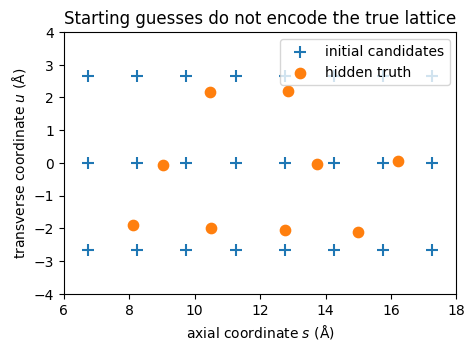

In [34]:
spacing_A = 2.35
row_height_A = spacing_A * np.sqrt(3.0) / 2.0
truth_positions = []
for row in range(3):
    row_s = 8.0 + (row % 2) * spacing_A / 2.0 + np.arange(4) * spacing_A
    for column, axial in enumerate(row_s):
        if (row == 1 and column == 1) or (row == 2 and column in (0, 3)):
            continue
        index = len(truth_positions)
        truth_positions.append([
            axial + 0.16 * np.sin(0.9 * (index + 1)),
            -2.0 + row * row_height_A + 0.12 * np.cos(0.7 * (index + 1)),
        ])

truth_positions_A = jnp.asarray(truth_positions)
truth_potential = render_free_atoms_1d(model, truth_positions_A, jnp.ones(9))

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.scatter(candidate_positions_A[:, 0], candidate_positions_A[:, 1], marker="+", s=75, label="initial candidates")
ax.scatter(truth_positions_A[:, 0], truth_positions_A[:, 1], s=55, label="hidden truth")
ax.set(xlabel="axial coordinate $s$ (Å)", ylabel="transverse coordinate $u$ (Å)",
       xlim=candidate_bounds_A[0], ylim=candidate_bounds_A[1])
ax.set_aspect("equal")
ax.legend()
ax.set_title("Starting guesses do not encode the true lattice")

## 3. Probe positions and overlap

Ptychography needs redundant, overlapping illuminations. Here 49 axial windows overlap strongly: each is 12 Å long and neighboring windows move by 0.25 Å. At every axial position, the Gaussian probe is shifted to nine transverse positions spanning the object. This gives $49\times9=441$ measurements—enough to constrain the much larger pixel model as well as the atomic models.

The first panel shows the intensity of one centred incident probe across a 12 Å window. The second places every **input probe centre directly on the hidden specimen**. White circles are used for training; cyan crosses are held out to compare convergence without fitting those data.

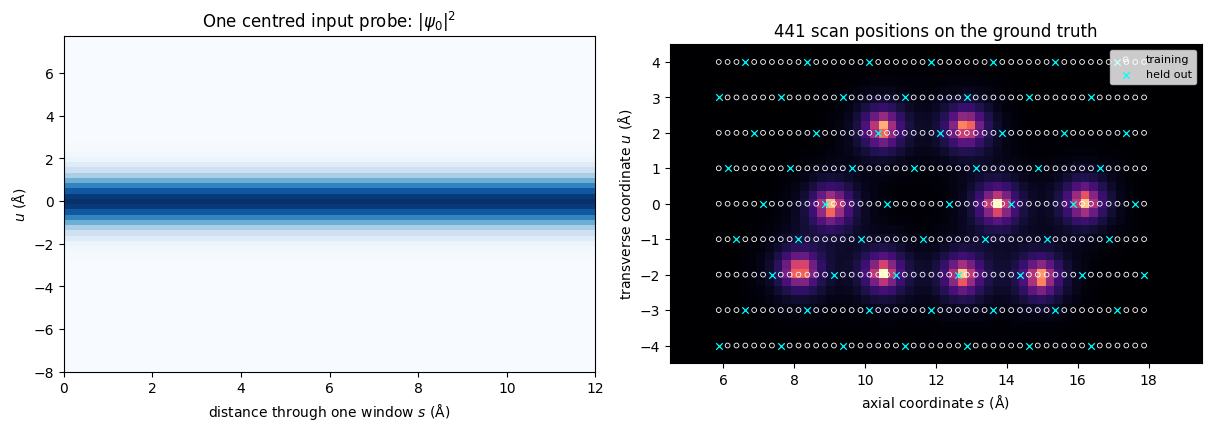

In [35]:
WINDOW_LENGTH = 48
kernel = fresnel_propagation_kernel_1d(N_U, SAMPLING_A, SAMPLING_A, ENERGY_EV)
axial_starts = np.arange(0, 49, dtype=np.int32)
probe_centres_A = np.arange(-4.0, 4.01, 1.0)
window_starts = jnp.asarray(np.repeat(axial_starts, len(probe_centres_A)))
scan_probe_centres_A = np.tile(probe_centres_A, len(axial_starts))
scan_axial_centres_A = (np.asarray(window_starts) + (WINDOW_LENGTH - 1) / 2) * SAMPLING_A

probes = jnp.stack([
    jnp.exp(-0.5 * ((u_A - centre) / 1.2) ** 2) * jnp.exp(0.12j * u_A)
    for centre in scan_probe_centres_A
])
validation_indices = np.arange(0, len(window_starts), 7)
is_validation = np.zeros(len(window_starts), dtype=bool)
is_validation[validation_indices] = True

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

# The incident probe is one-dimensional in u. Repeating it along s makes its
# intensity profile visible over one axial illumination window.
centred_probe_intensity = np.abs(np.asarray(probes[len(probe_centres_A) // 2])) ** 2
probe_image = np.repeat(centred_probe_intensity[:, None], WINDOW_LENGTH, axis=1)
axes[0].imshow(
    probe_image, origin="lower", aspect="auto", cmap="Blues",
    extent=[0, WINDOW_LENGTH * SAMPLING_A, float(u_A[0]), float(u_A[-1])],
)
axes[0].set(
    xlabel="distance through one window $s$ (Å)", ylabel="$u$ (Å)",
    title=r"One centred input probe: $|\psi_0|^2$",
)

truth_image = np.asarray(truth_potential).T
axes[1].imshow(
    truth_image, origin="lower", aspect="equal", cmap="magma",
    extent=[float(s_A[0]), float(s_A[-1]), float(u_A[0]), float(u_A[-1])],
)
axes[1].scatter(
    scan_axial_centres_A[~is_validation], scan_probe_centres_A[~is_validation],
    s=12, facecolors="none", edgecolors="white", linewidths=0.6, label="training",
)
axes[1].scatter(
    scan_axial_centres_A[is_validation], scan_probe_centres_A[is_validation],
    marker="x", s=22, color="cyan", linewidths=0.9, label="held out",
)
axes[1].set(
    xlabel="axial coordinate $s$ (Å)", ylabel="transverse coordinate $u$ (Å)",
    xlim=(4.5, 19.5), ylim=(-4.5, 4.5),
    title=f"{len(window_starts)} scan positions on the ground truth",
)
axes[1].legend(loc="upper right", fontsize=8)

In [36]:
measured = simulate_glancing_scan_1d(
    truth_potential, probes, window_starts, WINDOW_LENGTH,
    kernel, SAMPLING_A, ENERGY_EV,
)
print(f"Measurements: {len(window_starts)} ({len(window_starts) - len(validation_indices)} training, {len(validation_indices)} held out)")

Measurements: 441 (378 training, 63 held out)


## 4. What the atomic terms do

All atomic runs minimize the diffraction mismatch and a small **mass penalty**, which encourages unnecessary candidate occupancies to go to zero. They differ only in their pair term:

- **Atoms only — no pair force:** occupied candidates may approach or overlap. This isolates the benefit of describing the object as atoms.
- **Repulsion:** pairs closer than 1.8 Å receive a rapidly increasing quadratic penalty. It acts like a soft hard core and prevents duplicate atoms. It does not attract atoms or impose a lattice.
- **Weak cohesion:** a softened Lennard–Jones-like term has a minimum near 2.35 Å, fades out by 4 Å, and is introduced only late in optimization. It can gently favor plausible neighbors, but may bias the answer, so it is treated as an ablation rather than assumed to be correct.

These are regularizers, not a molecular-dynamics simulation: their gradients steer the inverse problem, and their numerical weights set their influence relative to the data mismatch.

In [37]:
common = dict(
    validation_indices=validation_indices,
    updates=1000,
    occupancy_only_updates=200,
    minibatch_size=18,
    validation_interval=20,
    progress=True,
)

atoms_only_result = reconstruct_free_atoms_1d(
    model, probes, window_starts, WINDOW_LENGTH, kernel, SAMPLING_A, ENERGY_EV, measured,
    repulsion_weight=0.0, progress_description="atoms only", **common,
)
repulsion_result = reconstruct_free_atoms_1d(
    model, probes, window_starts, WINDOW_LENGTH, kernel, SAMPLING_A, ENERGY_EV, measured,
    progress_description="atoms + repulsion", **common,
)
cohesion_result = reconstruct_free_atoms_1d(
    model, probes, window_starts, WINDOW_LENGTH, kernel, SAMPLING_A, ENERGY_EV, measured,
    cohesion_weight=1e-3, progress_description="atoms + weak cohesion", **common,
)

atoms only:   0%|          | 0/1000 [00:00<?, ?update/s]

atoms + repulsion:   0%|          | 0/1000 [00:00<?, ?update/s]

atoms + weak cohesion:   0%|          | 0/1000 [00:00<?, ?update/s]

## 5. Conventional ptychography: pixels and no atomic prior

For the baseline we fit the potential value at every allowed pixel. It uses exactly the same probe positions, measurements, forward propagation, training split, and held-out data. It contains **no atom templates, occupancies, repulsion, cohesion, known atom count, or lattice**.

The pixel support is the known specimen region plus a 1 Å margin. This is a generic compact-support assumption—not an atomic prior. Using the full 4 Å template cutoff would expose 5,184 pixels, including weak tails and poorly illuminated background, and make the inverse problem underdetermined. The compact mask has 2,337 unknowns, while the dense training scan supplies many more measured intensities.

In [38]:
pixel_support_margin_A = 1.0
pixel_mask = (
    (s_A[:, None] >= candidate_bounds_A[0, 0] - pixel_support_margin_A)
    & (s_A[:, None] <= candidate_bounds_A[0, 1] + pixel_support_margin_A)
    & (u_A[None, :] >= candidate_bounds_A[1, 0] - pixel_support_margin_A)
    & (u_A[None, :] <= candidate_bounds_A[1, 1] + pixel_support_margin_A)
)

pixel_result = reconstruct_potential_1d(
    jnp.zeros_like(truth_potential), pixel_mask, probes, window_starts, WINDOW_LENGTH,
    kernel, SAMPLING_A, ENERGY_EV, measured,
    axial_coordinates=s_A,
    transverse_coordinates=u_A,
    validation_indices=validation_indices,
    potential_scale=50.0,
    potential_max=150.0,
    updates=2000,
    minibatch_size=36,
    validation_interval=100,
    learning_rate_start=2e-2,
    learning_rate_end=2e-4,
    progress=True,
    progress_description="pixel baseline",
)

print(f"Pixel model: {int(pixel_mask.sum())} unknowns")
print(f"Training intensity samples: {(len(window_starts) - len(validation_indices)) * N_U}")
print(f"Atomic model: {3 * len(candidate_positions_A)} unknowns ({int(pixel_mask.sum()) / (3 * len(candidate_positions_A)):.1f}× fewer)")
pixel_relative_error = np.linalg.norm(np.asarray(pixel_result.potential - truth_potential)) / np.linalg.norm(np.asarray(truth_potential))
print(f"Pixel potential relative error (simulation only): {pixel_relative_error:.3f}")

pixel baseline:   0%|          | 0/2000 [00:00<?, ?update/s]

Pixel model: 2337 unknowns
Training intensity samples: 24192
Atomic model: 72 unknowns (32.5× fewer)
Pixel potential relative error (simulation only): 0.147


## 6. Which reconstruction converges fastest?

The left plot measures optimizer updates; the right measures recorded wall-clock time. Because the pixel solver stores squared amplitude loss while the atom solver stores its square root, we take the square root of the pixel history before comparing them. Thus every curve below is held-out amplitude NRMSE.

Wall time includes evaluation and JAX compilation encountered during each run, so it is useful for this notebook execution but is not a hardware-independent benchmark. The table reports the first recorded point below a common target.

[{'method': 'pixels (no atomic prior)',
  'unknowns': 2337,
  'best held-out NRMSE': 0.0006463581587215518,
  'updates to 0.001': 900,
  'seconds to 0.001': 19.009230573999957},
 {'method': 'atoms only',
  'unknowns': 72,
  'best held-out NRMSE': 3.334025867588895e-05,
  'updates to 0.001': 320,
  'seconds to 0.001': 5.276938979997794},
 {'method': 'atoms + repulsion',
  'unknowns': 72,
  'best held-out NRMSE': 2.2322666122549563e-05,
  'updates to 0.001': 660,
  'seconds to 0.001': 4.890098694002518},
 {'method': 'atoms + weak cohesion',
  'unknowns': 72,
  'best held-out NRMSE': 0.0013316849590274422,
  'updates to 0.001': 'not reached',
  'seconds to 0.001': 'not reached'}]

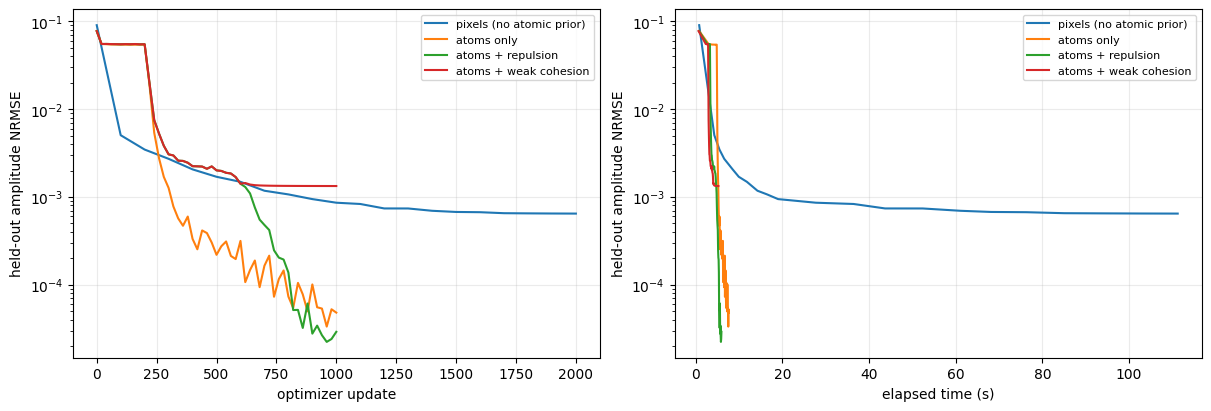

In [39]:
convergence = {
    "pixels (no atomic prior)": (
        np.asarray(pixel_result.update_history),
        np.asarray(pixel_result.elapsed_time_history),
        np.sqrt(np.asarray(pixel_result.validation_loss_history)),
    ),
    "atoms only": (
        np.asarray(atoms_only_result.update_history),
        np.asarray(atoms_only_result.elapsed_time_history),
        np.asarray(atoms_only_result.validation_loss_history),
    ),
    "atoms + repulsion": (
        np.asarray(repulsion_result.update_history),
        np.asarray(repulsion_result.elapsed_time_history),
        np.asarray(repulsion_result.validation_loss_history),
    ),
    "atoms + weak cohesion": (
        np.asarray(cohesion_result.update_history),
        np.asarray(cohesion_result.elapsed_time_history),
        np.asarray(cohesion_result.validation_loss_history),
    ),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for name, (updates, seconds, loss) in convergence.items():
    axes[0].semilogy(updates, loss, label=name)
    axes[1].semilogy(seconds, loss, label=name)
for ax, xlabel in zip(axes, ["optimizer update", "elapsed time (s)"]):
    ax.set(xlabel=xlabel, ylabel="held-out amplitude NRMSE")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

TARGET_NRMSE = 1e-3
rows = []
for name, (updates, seconds, loss) in convergence.items():
    reached = np.flatnonzero(loss <= TARGET_NRMSE)
    index = int(reached[0]) if len(reached) else None
    rows.append({
        "method": name,
        "unknowns": int(pixel_mask.sum()) if name.startswith("pixels") else 3 * len(candidate_positions_A),
        "best held-out NRMSE": float(np.nanmin(loss)),
        f"updates to {TARGET_NRMSE:g}": int(updates[index]) if index is not None else "not reached",
        f"seconds to {TARGET_NRMSE:g}": float(seconds[index]) if index is not None else "not reached",
    })
display(rows)

## 7. Did the atomic answers recover the structure?

Held-out diffraction agreement alone does not guarantee the correct atoms. We therefore also count occupied candidates, match them to the hidden truth within 0.5 Å, and report position error and the closest recovered pair. These truth-based metrics are available only because this is a simulation.

In [40]:
def atom_metrics(result, match_radius_A=0.5):
    active = np.asarray(result.occupancies) >= 0.5
    recovered = np.asarray(result.positions)[active]
    if len(recovered):
        distances = np.linalg.norm(recovered[:, None] - np.asarray(truth_positions_A)[None], axis=-1)
        rows, columns = linear_sum_assignment(distances)
        matched_distances = distances[rows, columns]
        true_positives = int(np.sum(matched_distances <= match_radius_A))
        rmse = float(np.sqrt(np.mean(matched_distances**2))) if len(recovered) == 9 else np.inf
        minimum_pair = float(np.min(pdist(recovered))) if len(recovered) > 1 else np.inf
    else:
        true_positives, rmse, minimum_pair = 0, np.inf, np.inf
    return {
        "active atoms": int(active.sum()),
        "false positives": int(active.sum()) - true_positives,
        "missing atoms": 9 - true_positives,
        "position RMSE (Å)": rmse,
        "closest pair (Å)": minimum_pair,
        "best held-out NRMSE": float(np.nanmin(result.validation_loss_history)),
    }

structural_metrics = {
    "atoms only": atom_metrics(atoms_only_result),
    "atoms + repulsion": atom_metrics(repulsion_result),
    "atoms + weak cohesion": atom_metrics(cohesion_result),
}
display(structural_metrics)

{'atoms only': {'active atoms': 9,
  'false positives': 0,
  'missing atoms': 0,
  'position RMSE (Å)': 0.01892088532259588,
  'closest pair (Å)': 2.0334088124220946,
  'best held-out NRMSE': 3.334025867588895e-05},
 'atoms + repulsion': {'active atoms': 9,
  'false positives': 0,
  'missing atoms': 0,
  'position RMSE (Å)': 0.00041508667580974205,
  'closest pair (Å)': 2.037317954962483,
  'best held-out NRMSE': 2.2322666122549563e-05},
 'atoms + weak cohesion': {'active atoms': 9,
  'false positives': 0,
  'missing atoms': 0,
  'position RMSE (Å)': 0.10481874563674931,
  'closest pair (Å)': 1.9216695083248052,
  'best held-out NRMSE': 0.0013316849590274422}}

Text(0, 0.5, '$s$ (Å)')

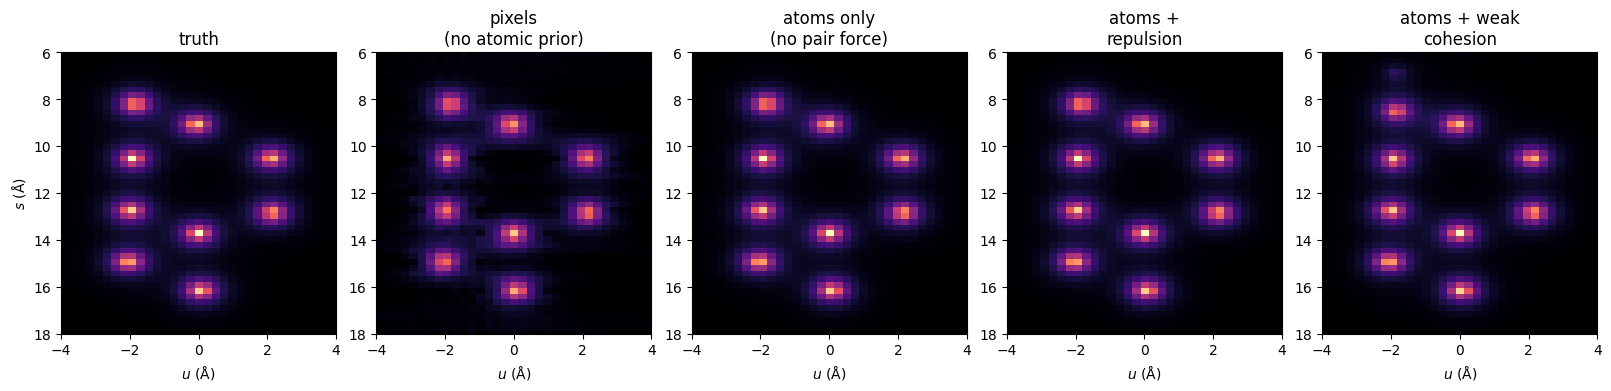

In [41]:
results = {
    "truth": truth_potential,
    "pixels\n(no atomic prior)": pixel_result.potential,
    "atoms only\n(no pair force)": atoms_only_result.potential,
    "atoms +\nrepulsion": repulsion_result.potential,
    "atoms + weak\ncohesion": cohesion_result.potential,
}
s_selected = np.where((np.asarray(s_A) >= candidate_bounds_A[0, 0]) & (np.asarray(s_A) <= candidate_bounds_A[0, 1]))[0]
u_selected = np.where((np.asarray(u_A) >= candidate_bounds_A[1, 0]) & (np.asarray(u_A) <= candidate_bounds_A[1, 1]))[0]
extent = [float(u_A[u_selected[0]]), float(u_A[u_selected[-1]]), float(s_A[s_selected[-1]]), float(s_A[s_selected[0]])]
truth_crop = np.asarray(truth_potential)[np.ix_(s_selected, u_selected)]
vmax = float(np.max(truth_crop))

fig, axes = plt.subplots(1, len(results), figsize=(16, 3.8), constrained_layout=True)
for ax, (name, potential) in zip(axes, results.items()):
    image = np.asarray(potential)[np.ix_(s_selected, u_selected)]
    ax.imshow(image, extent=extent, aspect="auto", vmin=0, vmax=vmax, cmap="magma")
    ax.set_title(name)
    ax.set_xlabel("$u$ (Å)")
axes[0].set_ylabel("$s$ (Å)")

## 8. If the element is unknown: a controlled two-species test

We now replace some Si atoms by much lighter C atoms. C and Si are deliberately well separated in atomic number, making this an optimistic first test of chemical sensitivity.

To keep the question interpretable, the nine positions are supplied in this section and only composition and occupancy are fitted. This asks **whether the diffraction geometry can distinguish the two templates**, not whether it can simultaneously find atoms and identify them. The four comparisons are:

- **Correct species supplied:** an oracle control with the true C/Si label at every known position.
- **Wrong single species:** every site is forced to be Si; fitted occupancy may partly hide that mistake.
- **Pixels:** no atom or element model at all.
- **Soft C/Si:** each site fits a C probability and a Si probability that sum to one. This is a categorical choice between templates, not a continuous fitted atomic number.

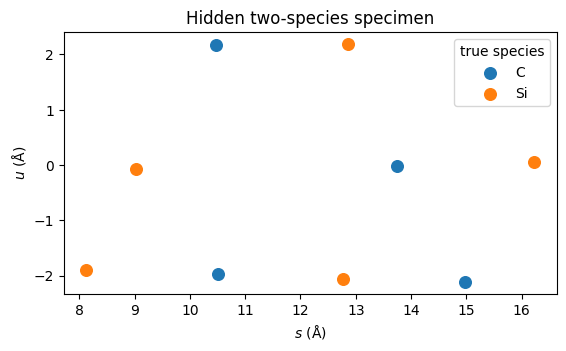

In [42]:
species_names = ("C", "Si")
species_templates = jnp.stack([
    make_atom_template_1d(name, SAMPLING_A, SAMPLING_A, cutoff_A=4.0)
    for name in species_names
])

# Alternating labels give four carbon and five silicon sites.
truth_species = (np.arange(len(truth_positions_A)) + 1) % 2
truth_species_probabilities = jax.nn.one_hot(truth_species, len(species_names))
two_species_truth = render_species_mixture_atoms_1d(
    model, species_templates, truth_positions_A, jnp.ones(9),
    truth_species_probabilities,
)
two_species_measured = simulate_glancing_scan_1d(
    two_species_truth, probes, window_starts, WINDOW_LENGTH,
    kernel, SAMPLING_A, ENERGY_EV,
)

fig, ax = plt.subplots(figsize=(8, 3.4))
for species_index, name in enumerate(species_names):
    selected = truth_species == species_index
    ax.scatter(
        np.asarray(truth_positions_A)[selected, 0],
        np.asarray(truth_positions_A)[selected, 1],
        s=70, label=name,
    )
ax.set(xlabel="$s$ (Å)", ylabel="$u$ (Å)", title="Hidden two-species specimen")
ax.set_aspect("equal")
ax.legend(title="true species")

### Fit composition at the known positions

The helper below is intentionally short. Occupancies are sigmoid parameters between 0 and 1. In the soft model, a softmax converts two logits into C/Si probabilities. A small entropy penalty encourages a clear choice instead of a permanent 50–50 mixture. All models are selected using the same held-out measurements as before.

In [43]:
training_indices = np.setdiff1d(np.arange(len(window_starts)), validation_indices)

def fit_composition(fixed_species_probabilities=None, *, updates=600, entropy_weight=1e-4):
    soft_species = fixed_species_probabilities is None
    values = {
        "occupancy_logits": jnp.full((9,), 2.0),
        "species_logits": jnp.zeros((9, len(species_names))),
    }

    def decode(parameters):
        occupancies = jax.nn.sigmoid(parameters["occupancy_logits"])
        probabilities = (
            jax.nn.softmax(parameters["species_logits"], axis=1)
            if soft_species else fixed_species_probabilities
        )
        return occupancies, probabilities

    def loss(parameters, indices, encourage_discrete):
        occupancies, probabilities = decode(parameters)
        potential = render_species_mixture_atoms_1d(
            model, species_templates, truth_positions_A, occupancies, probabilities,
        )
        prediction = simulate_glancing_scan_1d(
            potential, probes[indices], window_starts[indices], WINDOW_LENGTH,
            kernel, SAMPLING_A, ENERGY_EV,
        )
        data_nrmse = jnp.sqrt(
            normalized_amplitude_loss_1d(prediction, two_species_measured[indices]) + 1e-16
        )
        entropy = -jnp.mean(jnp.sum(probabilities * jnp.log(probabilities + 1e-12), axis=1))
        return data_nrmse + encourage_discrete * entropy

    held_out_indices = jnp.asarray(validation_indices)
    value_and_grad = jax.jit(jax.value_and_grad(
        lambda parameters, indices, weight: loss(parameters, indices, weight)
    ))
    held_out_loss = jax.jit(lambda parameters: loss(parameters, held_out_indices, 0.0))
    optimizer = optax.adam(2e-2)
    state = optimizer.init(values)
    rng = np.random.default_rng(0)
    history_updates, history_loss = [0], [float(held_out_loss(values))]
    best_values, best_loss = values, history_loss[0]

    for update in range(1, updates + 1):
        # Turn on discreteness gradually after the data fit has stabilized.
        weight = entropy_weight * max(0.0, (update - updates / 2) / (updates / 2))
        batch = jnp.asarray(rng.choice(training_indices, size=36, replace=False))
        _, gradient = value_and_grad(values, batch, weight if soft_species else 0.0)
        parameter_updates, state = optimizer.update(gradient, state, values)
        values = optax.apply_updates(values, parameter_updates)
        if update % 20 == 0:
            current_loss = float(held_out_loss(values))
            history_updates.append(update)
            history_loss.append(current_loss)
            if current_loss < best_loss:
                best_values, best_loss = values, current_loss

    occupancies, probabilities = decode(best_values)
    potential = render_species_mixture_atoms_1d(
        model, species_templates, truth_positions_A, occupancies, probabilities,
    )
    return {
        "potential": potential, "occupancies": occupancies,
        "probabilities": probabilities, "updates": np.asarray(history_updates),
        "held_out_nrmse": np.asarray(history_loss),
    }

oracle_result = fit_composition(truth_species_probabilities)
all_si_probabilities = jax.nn.one_hot(jnp.ones(9, dtype=int), len(species_names))
wrong_si_result = fit_composition(all_si_probabilities)
soft_species_result = fit_composition()

In [44]:
two_species_pixel_result = reconstruct_potential_1d(
    jnp.zeros_like(two_species_truth), pixel_mask, probes, window_starts, WINDOW_LENGTH,
    kernel, SAMPLING_A, ENERGY_EV, two_species_measured,
    axial_coordinates=s_A, transverse_coordinates=u_A,
    validation_indices=validation_indices, potential_scale=50.0, potential_max=150.0,
    updates=2000, minibatch_size=36, validation_interval=100,
    learning_rate_start=2e-2, learning_rate_end=2e-4,
    progress=True, progress_description="two-species pixel baseline",
)

two-species pixel baseline:   0%|          | 0/2000 [00:00<?, ?update/s]

### Read the result

The held-out NRMSE is the normalized error between **diffraction amplitudes** $\sqrt{I}$: $\|\sqrt{I_\mathrm{pred}}-\sqrt{I_\mathrm{meas}}\|_2/\|\sqrt{I_\mathrm{meas}}\|_2$. It is evaluated only at probe positions excluded from optimization. Species accuracy is a stronger simulation-only check. Pay special attention to the wrong-Si occupancies: values below one show how occupancy can compensate for an incorrect scattering strength. A low diffraction error alone therefore does not prove chemical identification.

[{'method': 'correct species supplied',
  'best held-out NRMSE': 0.0002141807147176463,
  'species accuracy': 1.0,
  'mean occupancy': 0.9971234901805666},
 {'method': 'wrong: all Si',
  'best held-out NRMSE': 0.0030677919135379517,
  'species accuracy': 0.5555555555555556,
  'mean occupancy': 0.7963633672111993},
 {'method': 'pixels',
  'best held-out NRMSE': 0.00029250668485562354,
  'species accuracy': 'not defined',
  'mean occupancy': 'not defined'},
 {'method': 'soft C/Si',
  'best held-out NRMSE': 0.0002957756614157661,
  'species accuracy': 1.0,
  'mean occupancy': 0.9857437260608723}]

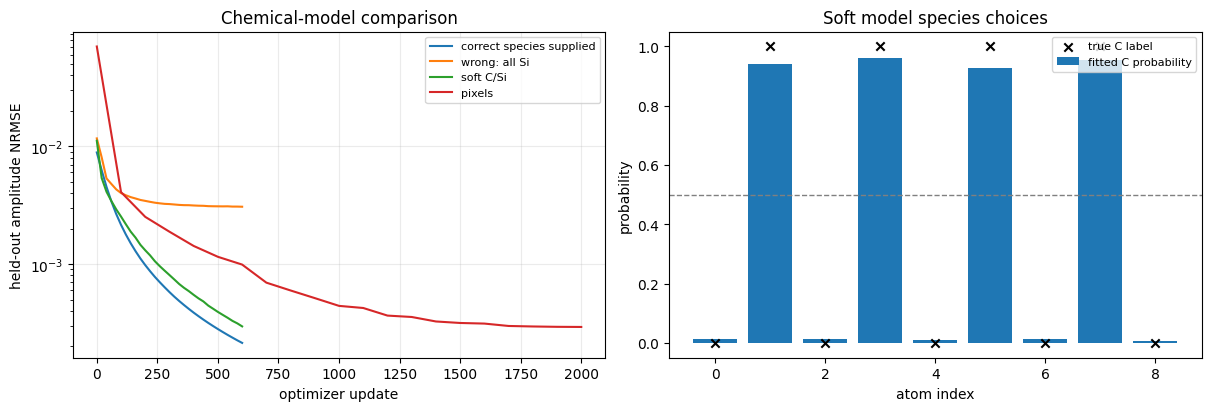

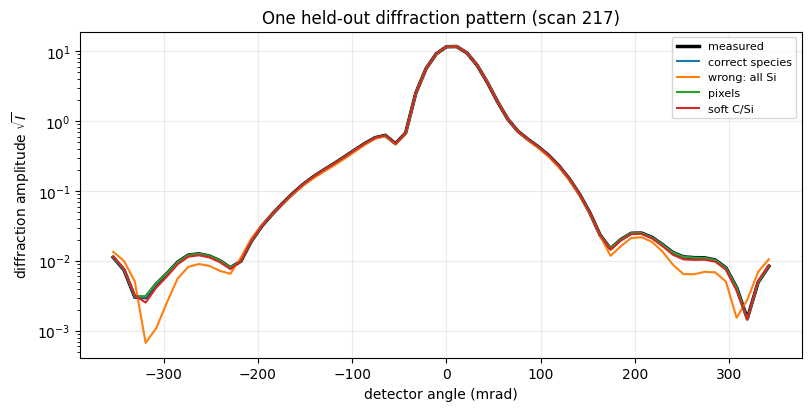

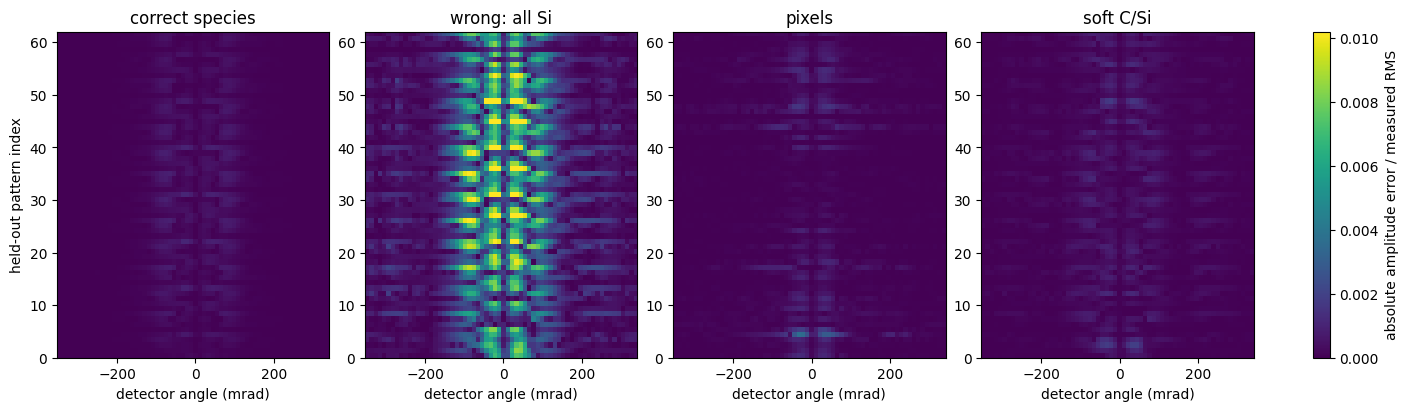

In [45]:
soft_labels = np.argmax(np.asarray(soft_species_result["probabilities"]), axis=1)
chemistry_summary = [
    {
        "method": "correct species supplied",
        "best held-out NRMSE": float(np.min(oracle_result["held_out_nrmse"])),
        "species accuracy": 1.0,
        "mean occupancy": float(np.mean(oracle_result["occupancies"])),
    },
    {
        "method": "wrong: all Si",
        "best held-out NRMSE": float(np.min(wrong_si_result["held_out_nrmse"])),
        "species accuracy": float(np.mean(truth_species == 1)),
        "mean occupancy": float(np.mean(wrong_si_result["occupancies"])),
    },
    {
        "method": "pixels",
        "best held-out NRMSE": float(np.sqrt(np.min(two_species_pixel_result.validation_loss_history))),
        "species accuracy": "not defined",
        "mean occupancy": "not defined",
    },
    {
        "method": "soft C/Si",
        "best held-out NRMSE": float(np.min(soft_species_result["held_out_nrmse"])),
        "species accuracy": float(np.mean(soft_labels == truth_species)),
        "mean occupancy": float(np.mean(soft_species_result["occupancies"])),
    },
]
display(chemistry_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for name, result in [
    ("correct species supplied", oracle_result),
    ("wrong: all Si", wrong_si_result),
    ("soft C/Si", soft_species_result),
]:
    axes[0].semilogy(result["updates"], result["held_out_nrmse"], label=name)
axes[0].semilogy(
    two_species_pixel_result.update_history,
    np.sqrt(two_species_pixel_result.validation_loss_history),
    label="pixels",
)
axes[0].set(xlabel="optimizer update", ylabel="held-out amplitude NRMSE", title="Chemical-model comparison")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

x = np.arange(9)
axes[1].bar(x, np.asarray(soft_species_result["probabilities"])[:, 0], label="fitted C probability")
axes[1].scatter(x, truth_species == 0, color="black", marker="x", label="true C label")
axes[1].axhline(0.5, color="grey", linewidth=1, linestyle="--")
axes[1].set(xlabel="atom index", ylabel="probability", ylim=(-0.05, 1.05), title="Soft model species choices")
axes[1].legend(fontsize=8)

# Show what the held-out amplitude NRMSE is comparing.
held_out = jnp.asarray(validation_indices)
def predict_held_out(potential):
    return simulate_glancing_scan_1d(
        potential, probes[held_out], window_starts[held_out], WINDOW_LENGTH,
        kernel, SAMPLING_A, ENERGY_EV,
    )

held_out_intensities = {
    "measured": two_species_measured[held_out],
    "correct species": predict_held_out(oracle_result["potential"]),
    "wrong: all Si": predict_held_out(wrong_si_result["potential"]),
    "pixels": two_species_pixel_result.predicted_intensities[held_out],
    "soft C/Si": predict_held_out(soft_species_result["potential"]),
}
held_out_amplitudes = {
    name: np.sqrt(np.clip(np.asarray(intensity), 0.0, None))
    for name, intensity in held_out_intensities.items()
}
detector_angles_mrad = np.asarray(two_species_pixel_result.detector_angles)
example_row = len(validation_indices) // 2

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for name, amplitude in held_out_amplitudes.items():
    style = dict(color="black", linewidth=2.5) if name == "measured" else {}
    ax.semilogy(detector_angles_mrad, amplitude[example_row] + 1e-12, label=name, **style)
ax.set(
    xlabel="detector angle (mrad)", ylabel=r"diffraction amplitude $\sqrt{I}$",
    title=f"One held-out diffraction pattern (scan {validation_indices[example_row]})",
)
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

measured_amplitude = held_out_amplitudes["measured"]
amplitude_scale = np.sqrt(np.mean(measured_amplitude**2))
residuals = {
    name: np.abs(amplitude - measured_amplitude) / amplitude_scale
    for name, amplitude in held_out_amplitudes.items() if name != "measured"
}
residual_vmax = max(np.percentile(residual, 99) for residual in residuals.values())
fig, axes = plt.subplots(1, len(residuals), figsize=(14, 4), constrained_layout=True)
for ax, (name, residual) in zip(axes, residuals.items()):
    image = ax.imshow(
        residual, origin="lower", aspect="auto", cmap="viridis",
        vmin=0, vmax=residual_vmax,
        extent=[detector_angles_mrad[0], detector_angles_mrad[-1], 0, len(validation_indices) - 1],
    )
    ax.set(title=name, xlabel="detector angle (mrad)")
axes[0].set_ylabel("held-out pattern index")
fig.colorbar(image, ax=axes, label="absolute amplitude error / measured RMS")

Text(0, 0.5, '$s$ (Å)')

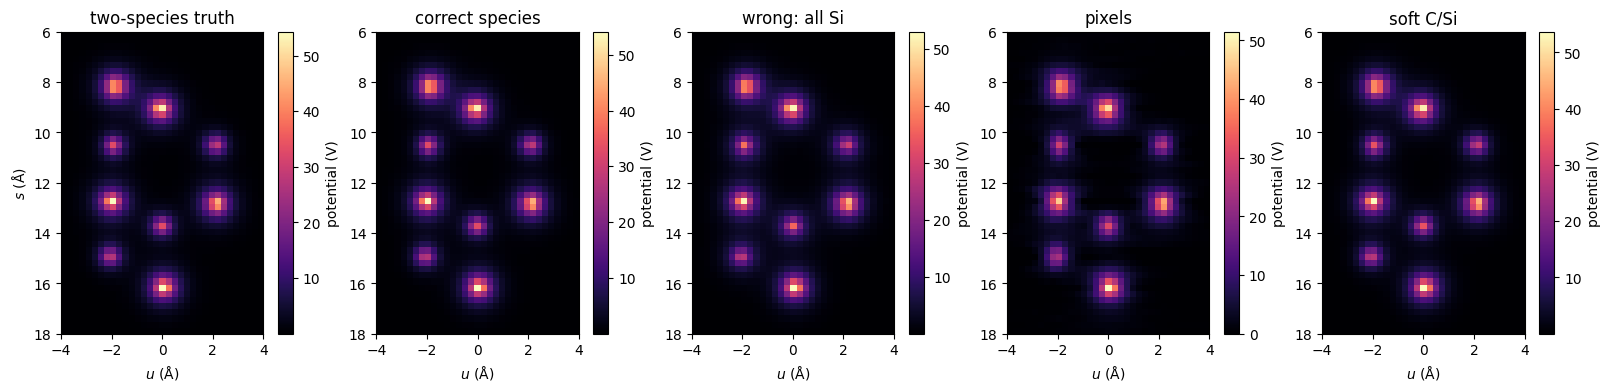

In [47]:
chemical_results = {
    "two-species truth": two_species_truth,
    "correct species": oracle_result["potential"],
    "wrong: all Si": wrong_si_result["potential"],
    "pixels": two_species_pixel_result.potential,
    "soft C/Si": soft_species_result["potential"],
}
chemical_vmax = float(np.max(np.asarray(two_species_truth)[np.ix_(s_selected, u_selected)]))
fig, axes = plt.subplots(1, len(chemical_results), figsize=(16, 3.8), constrained_layout=True)
for ax, (name, potential) in zip(axes, chemical_results.items()):
    image = np.asarray(potential)[np.ix_(s_selected, u_selected)]
    im = ax.imshow(image, extent=extent, aspect="auto", cmap="magma")
    ax.set_title(name)
    ax.set_xlabel("$u$ (Å)")
    plt.colorbar(im, ax=ax, label="potential (V)")
axes[0].set_ylabel("$s$ (Å)")

## Take-away

The pixel reconstruction is the clean “no atomic physics” control: it asks the diffraction data to determine many independent potential values. The first atomic experiment is more accurately called **free-position silicon atoms** because its template fixes the species. Repulsion adds only an excluded-volume rule; cohesion adds a weak preferred neighbor distance.

The C/Si experiment is a first identifiability check, not a general unknown-$Z$ solver. It asks a deliberately easier question at known positions and with two well-separated candidate elements. If the soft probabilities remain ambiguous, or the wrong-Si model fits nearly as well by changing occupancy, this geometry does not uniquely determine chemistry. Noise, unknown positions, similar neighboring elements, probe error, and three-dimensional specimens all make the problem harder.